In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load dataset
df = pd.read_csv("/content/Task Catagories.csv.csv")

# Encode categorical variables
label_encoders = {}
for col in ["Category", "Skill"]:
    label_encoders[col] = LabelEncoder()
    df[col] = label_encoders[col].fit_transform(df[col])

# Features and target
X = df[["Category"]]
y = df["Skill"]

# Split into training & testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [3]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Define models
models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

# Compare models
best_model = None
best_score = 0

for name, model in models.items():
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    print(f"{name} Accuracy: {score:.2f}")
    if score > best_score:
        best_model = model
        best_score = score



Decision Tree Accuracy: 0.10
Random Forest Accuracy: 0.10


In [4]:
# Train best model
best_model.fit(X_train, y_train)
print("✅ Model training complete!")


✅ Model training complete!


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np



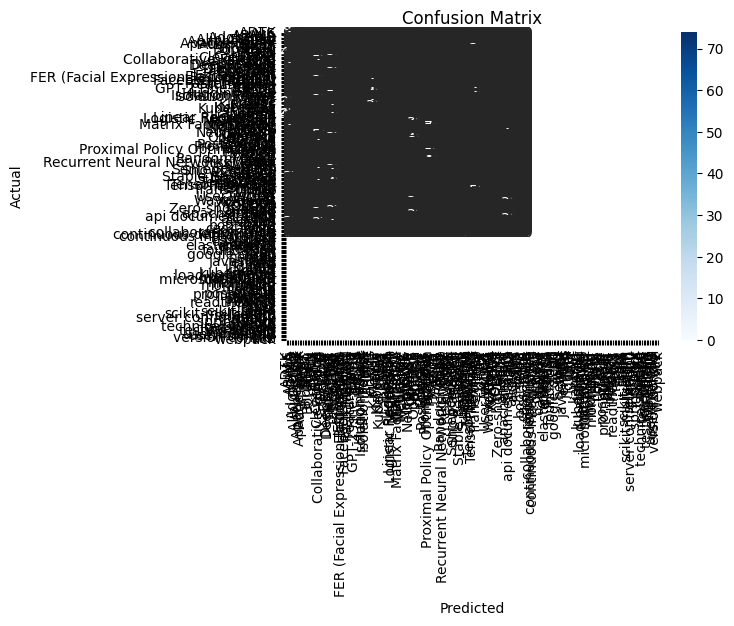

In [7]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoders["Skill"].classes_, yticklabels=label_encoders["Skill"].classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


<ipython-input-8-3d11740a2c1c>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics, y=values, palette="viridis")


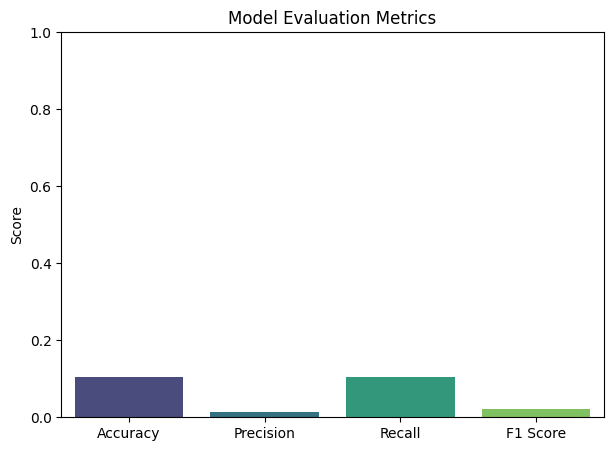

In [8]:
# Metrics
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
values = [accuracy, precision, recall, f1]

# Plot metrics
plt.figure(figsize=(7,5))
sns.barplot(x=metrics, y=values, palette="viridis")
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Model Evaluation Metrics")
plt.show()


In [9]:
from sklearn.metrics import roc_curve, auc

# Check if it's binary classification
if len(np.unique(y_test)) == 2:
    y_prob = best_model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color="gray", linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()
else:
    print("⚠️ ROC Curve only applicable for binary classification!")


⚠️ ROC Curve only applicable for binary classification!


In [10]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {"max_depth": [3, 5, 10], "min_samples_split": [2, 5, 10]}

# Hyperparameter tuning using GridSearchCV
grid_search = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5)
grid_search.fit(X_train, y_train)

# Best parameters
print("✅ Best Parameters:", grid_search.best_params_)


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


✅ Best Parameters: {'max_depth': 10, 'min_samples_split': 2}


In [11]:
import numpy as np

new_data = pd.DataFrame({"Task Description": ["Build API"], "Category": ["Backend"]})

# Encode category
if new_data["Category"][0] in label_encoders["Category"].classes_:
    new_data["Category"] = label_encoders["Category"].transform(new_data["Category"])
else:
    new_data["Category"] = np.nan  # Handle unknown category

# Predict
prediction = best_model.predict(new_data[["Category"]])
new_data["Predicted Skill"] = label_encoders["Skill"].inverse_transform(prediction)

print("\n✅ Prediction Output:\n", new_data)



✅ Prediction Output:
   Task Description  Category Predicted Skill
0        Build API       NaN     materialize


In [12]:
# Function to update model with new data
def update_model(new_data_path):
    new_df = pd.read_csv(new_data_path)

    # Encode and train on new data
    for col in ["Category", "Skill"]:
        new_df[col] = label_encoders[col].transform(new_df[col])

    X_new = new_df[["Category"]]
    y_new = new_df["Skill"]

    # Retrain model
    best_model.fit(X_new, y_new)
    joblib.dump((best_model, label_encoders), "task_model.pkl")
    print("✅ Model updated successfully!")

# Call function with new data
# update_model("new_task_data.csv")


In [14]:
from google.colab import drive
drive.mount('/content/drive')  # Mount Google Drive


Mounted at /content/drive
